In [1]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as geopd

In [3]:
claim_freq = pl.read_csv('freMTPL2freq.csv', schema_overrides={
    'IDpol': pl.Float64})
claim_sev = pl.read_csv('freMTPL2sev.csv')

In [4]:
claim_freq = claim_freq.with_columns(pl.col("IDpol").cast(pl.Int64))

In [6]:
claim_freq.shape

(678013, 12)

In [5]:
claim_sev.shape

(26639, 2)

In [7]:
claims = claim_freq.join(claim_sev, on='IDpol', how='left')

In [8]:
claims.null_count()

IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,653069


In [9]:
claims.head()

IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
i64,i64,f64,str,i64,i64,i64,i64,str,str,i64,str,f64
1,1,0.1,"""'D'""",5,0,55,50,"""'B12'""","""'Regular'""",1217,"""'R82'""",null
3,1,0.77,"""'D'""",5,0,55,50,"""'B12'""","""'Regular'""",1217,"""'R82'""",null
5,1,0.75,"""'B'""",6,2,52,50,"""'B12'""","""'Diesel'""",54,"""'R22'""",null
10,1,0.09,"""'B'""",7,0,46,50,"""'B12'""","""'Diesel'""",76,"""'R72'""",null
11,1,0.84,"""'B'""",7,0,46,50,"""'B12'""","""'Diesel'""",76,"""'R72'""",null


In [10]:
claims.describe()

statistic,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
str,f64,f64,f64,str,f64,f64,f64,f64,str,str,f64,str,f64
"""count""",679513.0,679513.0,679513.0,"""679513""",679513.0,679513.0,679513.0,679513.0,"""679513""","""679513""",679513.0,"""679513""",26444.0
"""null_count""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0""",0.0,"""0""",653069.0
"""mean""",2.6217e6,0.058554,0.529078,null,6.454486,7.043808,45.497617,59.784621,null,null,1794.052255,null,2265.512649
"""std""",1.6418e6,0.279196,0.364378,null,2.05099,5.664855,14.140106,15.666953,null,null,3960.829098,null,29371.031113
"""min""",1.0,0.0,0.002732,"""'A'""",4.0,0.0,18.0,50.0,"""'B1'""","""'Diesel'""",1.0,"""'R11'""",1.0
"""25%""",1.157893e6,0.0,0.18,null,5.0,2.0,34.0,50.0,null,null,92.0,null,686.02
"""50%""",2.272111e6,0.0,0.49,null,6.0,6.0,44.0,50.0,null,null,393.0,null,1172.0
"""75%""",4.04621e6,0.0,0.99,null,7.0,11.0,55.0,64.0,null,null,1658.0,null,1212.31
"""max""",6.11433e6,16.0,2.01,"""'F'""",15.0,100.0,100.0,230.0,"""'B6'""","""'Regular'""",27000.0,"""'R94'""",4.0754e6


In [11]:
claims.shape

(679513, 13)

In [12]:
claims.dtypes

[Int64,
 Int64,
 Float64,
 String,
 Int64,
 Int64,
 Int64,
 Int64,
 String,
 String,
 Int64,
 String,
 Float64]

In [15]:
claims["Region"].unique()

Region
str
"""R83"""
"""R52"""
"""R72"""
"""R74"""
"""R41"""
…
"""R43"""
"""R25"""
"""R11"""


In [14]:
claims = claims.with_columns(pl.col("Region").str.replace_all("'", ""),
                             pl.col("Area").str.replace_all("'", ""),
                             pl.col("VehBrand").str.replace_all("'", ""),
                             pl.col("VehGas").str.replace_all("'", ""))

In [16]:
gdf_france = geopd.read_file("regions-20140306-100m-shp/regions-20140306-100m.shp")
gdf_france.head()

,code_insee,nom,nom_cl,insee_cl,nuts2,iso3166_2,wikipedia,nb_dep,nb_comm,surf_km2,geometry
0,42,Alsace,Strasbourg,67482,FR42,None,fr:Alsace,2,904,8328.0,"POLYGON ((7.43003 47.45949, 7.4288 47.45388, 7..."
1,72,Aquitaine,Bordeaux,33063,FR61,None,fr:Aquitaine,5,2296,41818.0,"MULTIPOLYGON (((-1.75633 43.38372, -1.7559 43...."
2,83,Auvergne,Clermont-Ferrand,63113,FR72,None,fr:Auvergne,4,1310,26172.0,"POLYGON ((3.3369 44.95609, 3.31531 44.94425, 3..."
3,25,Basse-Normandie,Caen,14118,FR25,None,fr:Basse-Normandie,3,1812,17786.0,"MULTIPOLYGON (((-1.51504 48.66027, -1.51304 48..."
4,26,Bourgogne,Dijon,21231,FR26,None,fr:Bourgogne,4,2046,31752.0,"POLYGON ((4.76293 46.17583, 4.75864 46.17205, ..."


<Axes: >

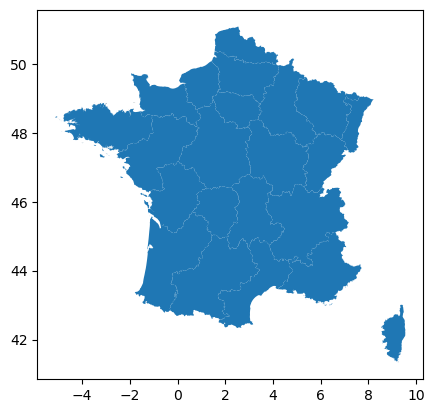

In [17]:
# filter out over-see regions
gdf_france = gdf_france[~gdf_france["nom"].isin(["Guadeloupe", "Guyane", "La Réunion", "Martinique", "Mayotte"])]
# define region to match the insurance data set
gdf_france['Region'] = "R" + gdf_france['code_insee']
# plot
gdf_france.plot()

In [18]:
set(gdf_france['Region']) == set(claims['Region'])

True

In [21]:
claims = claims.with_columns(
    (pl.col("ClaimNb") / pl.col("Exposure")).alias("ClaimFreq")
)
claims = claims.with_columns(
    (pl.col("ClaimFreq") + 10**-10).alias("ClaimFreqOffset")
)

In [23]:
claims.head()

IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount,ClaimFreq,ClaimFreqOffset
i64,i64,f64,str,i64,i64,i64,i64,str,str,i64,str,f64,f64,f64
1,1,0.1,"""D""",5,0,55,50,"""B12""","""Regular""",1217,"""R82""",null,10.0,10.0
3,1,0.77,"""D""",5,0,55,50,"""B12""","""Regular""",1217,"""R82""",null,1.298701,1.298701
5,1,0.75,"""B""",6,2,52,50,"""B12""","""Diesel""",54,"""R22""",null,1.333333,1.333333
10,1,0.09,"""B""",7,0,46,50,"""B12""","""Diesel""",76,"""R72""",null,11.111111,11.111111
11,1,0.84,"""B""",7,0,46,50,"""B12""","""Diesel""",76,"""R72""",null,1.190476,1.190476


In [24]:
claims.describe()

statistic,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount,ClaimFreq,ClaimFreqOffset
str,f64,f64,f64,str,f64,f64,f64,f64,str,str,f64,str,f64,f64,f64
"""count""",679513.0,679513.0,679513.0,"""679513""",679513.0,679513.0,679513.0,679513.0,"""679513""","""679513""",679513.0,"""679513""",26444.0,679513.0,679513.0
"""null_count""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0""",0.0,"""0""",653069.0,0.0,0.0
"""mean""",2.6217e6,0.058554,0.529078,null,6.454486,7.043808,45.497617,59.784621,null,null,1794.052255,null,2265.512649,0.281781,0.281781
"""std""",1.6418e6,0.279196,0.364378,null,2.05099,5.664855,14.140106,15.666953,null,null,3960.829098,null,29371.031113,4.731302,4.731302
"""min""",1.0,0.0,0.002732,"""A""",4.0,0.0,18.0,50.0,"""B1""","""Diesel""",1.0,"""R11""",1.0,0.0,1.0000e-10
"""25%""",1.157893e6,0.0,0.18,null,5.0,2.0,34.0,50.0,null,null,92.0,null,686.02,0.0,1.0000e-10
"""50%""",2.272111e6,0.0,0.49,null,6.0,6.0,44.0,50.0,null,null,393.0,null,1172.0,0.0,1.0000e-10
"""75%""",4.04621e6,0.0,0.99,null,7.0,11.0,55.0,64.0,null,null,1658.0,null,1212.31,0.0,1.0000e-10
"""max""",6.11433e6,16.0,2.01,"""F""",15.0,100.0,100.0,230.0,"""B6""","""Regular""",27000.0,"""R94""",4.0754e6,732.0,732.0


ClaimNb

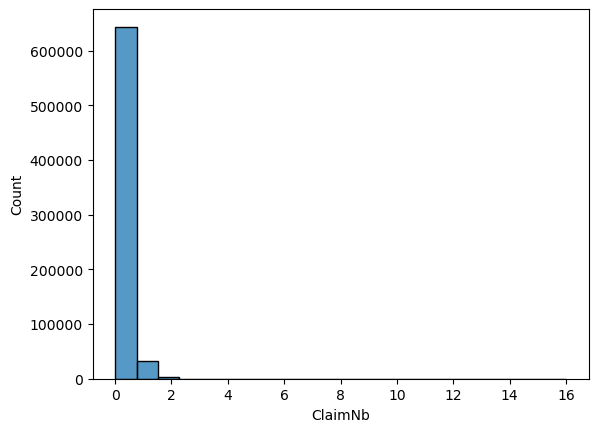

In [25]:
_ = sns.histplot(x=claims['ClaimNb'])

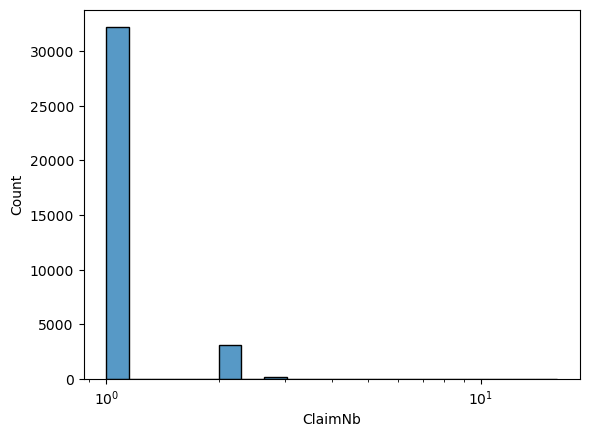

In [27]:
_ = sns.histplot(x=claims['ClaimNb'], log_scale=True, bins=20)

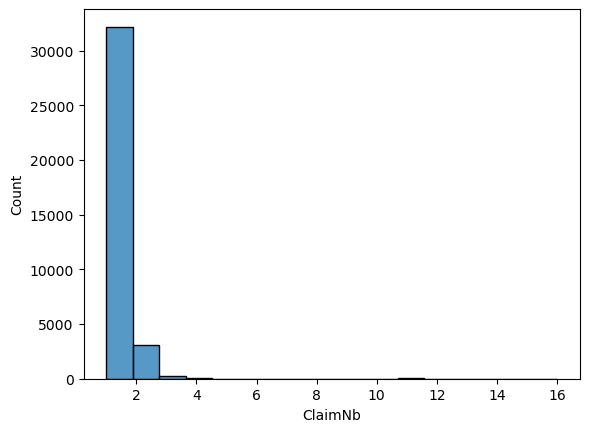

In [33]:
_ = sns.histplot(data=claims.filter(pl.col("ClaimNb") != 0), x='ClaimNb')

In [34]:
total_claims_region = claims.group_by("Region").agg(pl.col("ClaimNb").sum())

In [38]:
total_claims_region.head()

,Region,ClaimNb
0,R91,2343
1,R43,61
2,R72,1496
3,R42,151
4,R94,297


In [36]:
total_claims_region = total_claims_region.to_pandas()

In [39]:
gdf_france = gdf_france.merge(total_claims_region, how="left", on="Region")

In [40]:
gdf_france = gdf_france.rename(columns={"ClaimNb": "ClaimNbSum"})

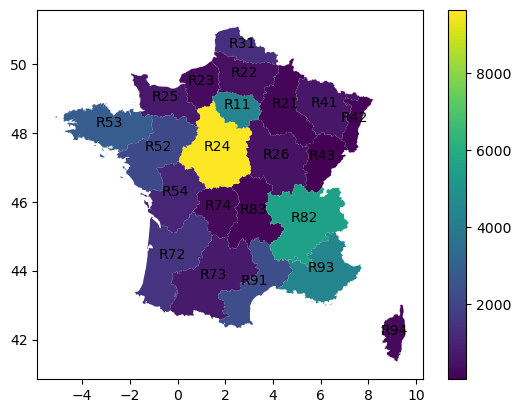

In [41]:
ax = gdf_france.plot(column="ClaimNbSum", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

In [42]:
mean_claims_region = claims.group_by("Region").agg(pl.col("ClaimNb").mean())
mean_claims_region = mean_claims_region.to_pandas()
gdf_france = gdf_france.merge(mean_claims_region, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"ClaimNb": "ClaimNbMean"})

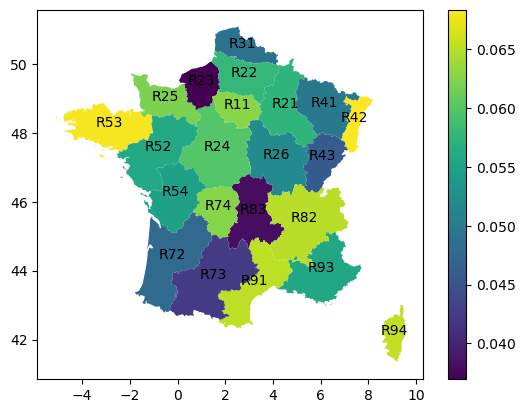

In [43]:
ax = gdf_france.plot(column="ClaimNbMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

ClaimFreq

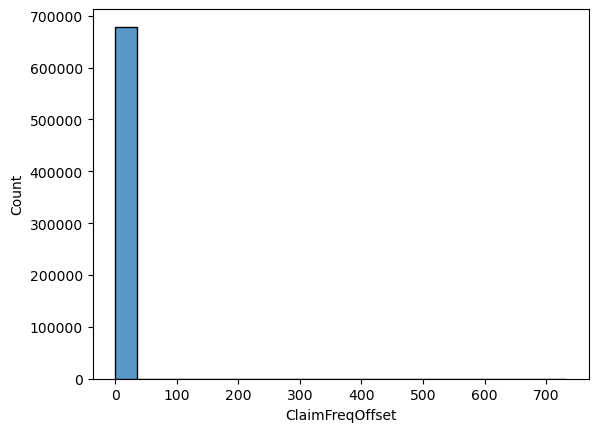

In [44]:
_ = sns.histplot(x=claims['ClaimFreqOffset'])

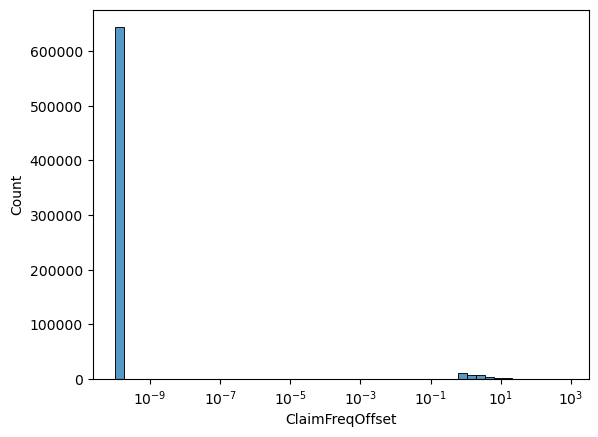

In [45]:
_ = sns.histplot(x=claims['ClaimFreqOffset'], log_scale=True, bins=50)

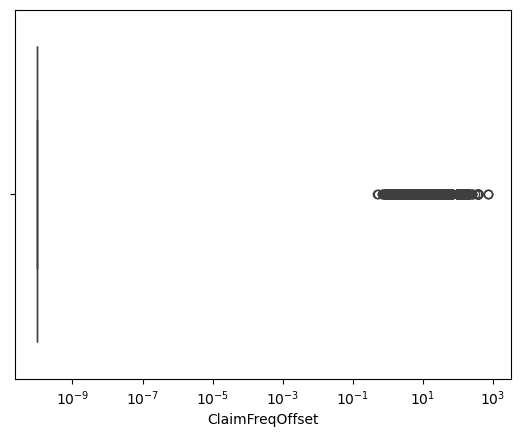

In [46]:
_ = sns.boxplot(data=claims ,x='ClaimFreqOffset', log_scale=True)

In [47]:
mean_claimsfreq_region = claims.group_by("Region").agg(pl.col("ClaimFreqOffset").mean())
mean_claimsfreq_region = mean_claimsfreq_region.to_pandas()
gdf_france = gdf_france.merge(mean_claimsfreq_region, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"ClaimFreqOffset": "ClaimFreqOffsetMean"})

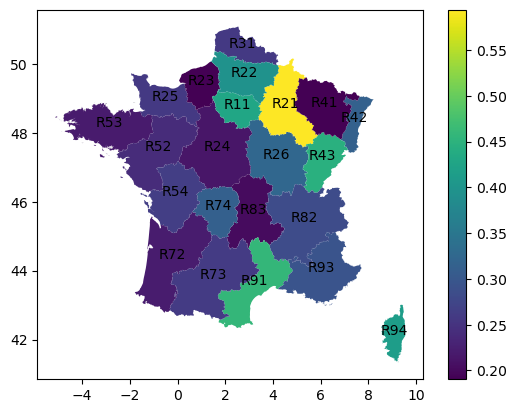

In [48]:
ax = gdf_france.plot(column="ClaimFreqOffsetMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

ClaimAmount

In [49]:
claim_sev["ClaimAmount"].head()

ClaimAmount
f64
995.2
1128.12
1851.11
1204.0
1204.0
1204.0
1204.0
54942.62
7620.0


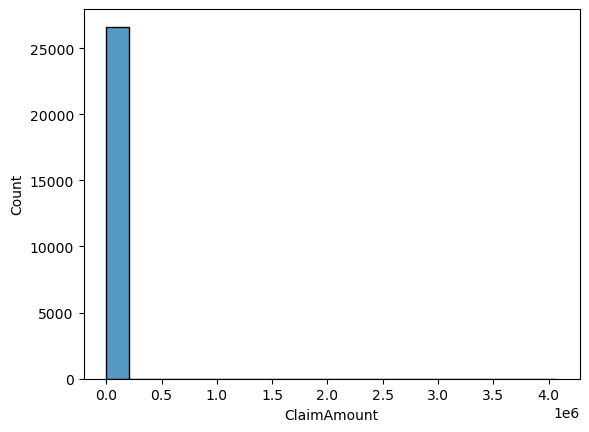

In [50]:
_ = sns.histplot(x=claim_sev["ClaimAmount"], bins=20)

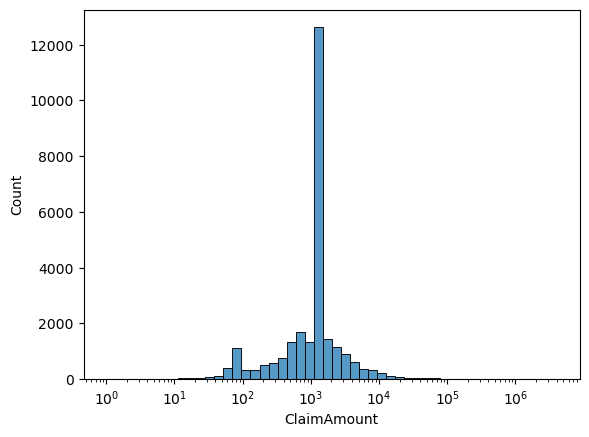

In [51]:
_ = sns.histplot(x=claim_sev["ClaimAmount"], bins=50, log_scale=True)

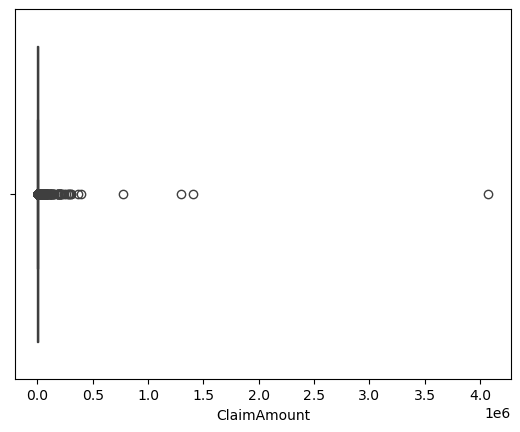

In [52]:
_ = sns.boxplot(x=claim_sev["ClaimAmount"])

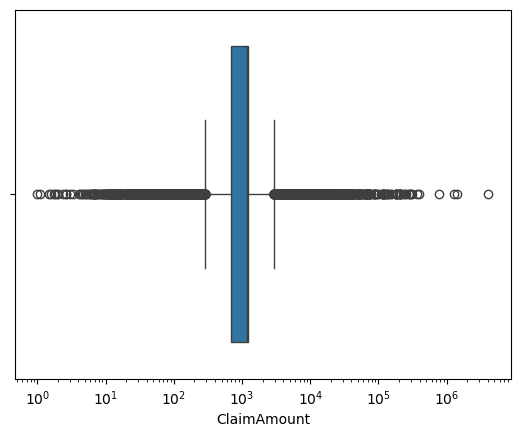

In [53]:
_ = sns.boxplot(x=claim_sev["ClaimAmount"], log_scale=True)

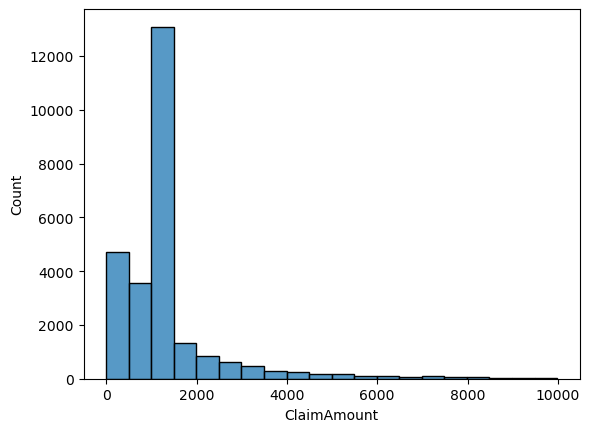

In [55]:
_ = sns.histplot(data=claim_sev.filter(pl.col("ClaimAmount") < 10000), x="ClaimAmount", bins=20)

In [56]:
mean_claim_amount_region = claims.group_by("Region").agg(pl.col("ClaimAmount").mean())
mean_claim_amount_region = mean_claim_amount_region.to_pandas()
gdf_france = gdf_france.merge(mean_claim_amount_region, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"ClaimAmount": "ClaimAmountMean"})

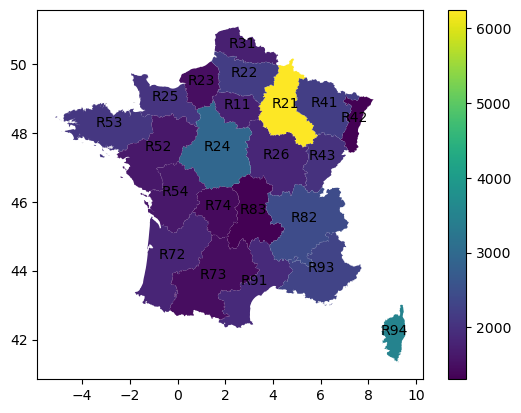

In [57]:
ax = gdf_france.plot(column="ClaimAmountMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

Extremely long right tail. It looks more normal in the log scale when zeroes are removed

Exposure

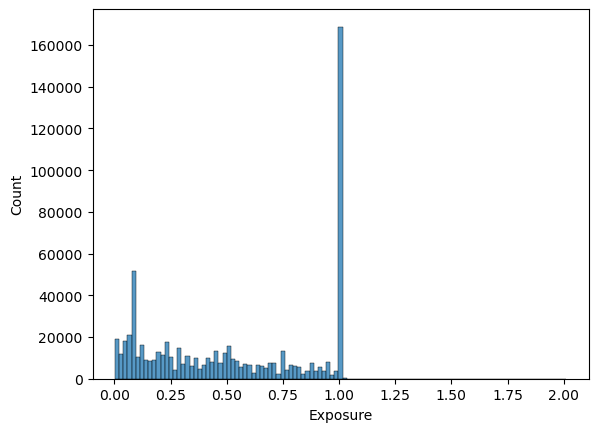

In [58]:
_ = sns.histplot(x=claims['Exposure'])

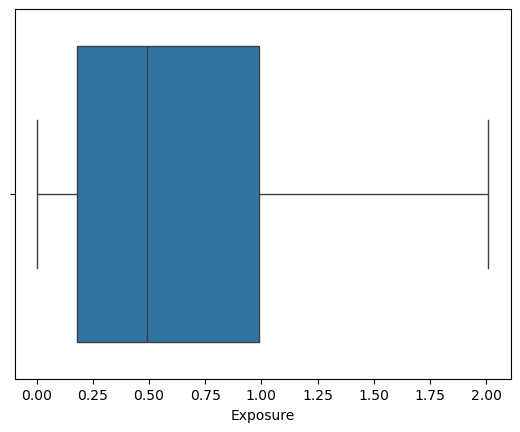

In [59]:
_ = sns.boxplot(x=claims['Exposure'])

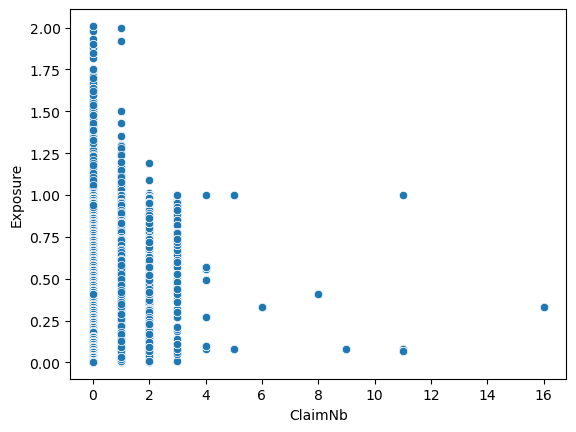

In [60]:
_ = sns.scatterplot(x=claims['ClaimNb'], y=claims['Exposure'])

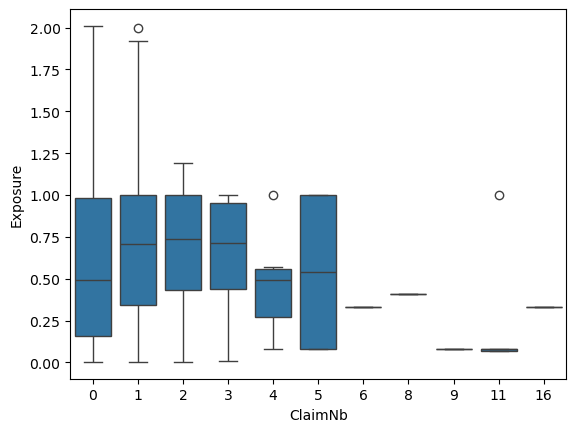

In [61]:
_ = sns.boxplot(x=claims['ClaimNb'], y=claims['Exposure'])

In [62]:
region_exposure = claims.group_by("Region").agg(pl.col("Exposure").sum())
region_exposure = region_exposure.to_pandas()
gdf_france = gdf_france.merge(region_exposure, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"Exposure": "ExposureSum"})

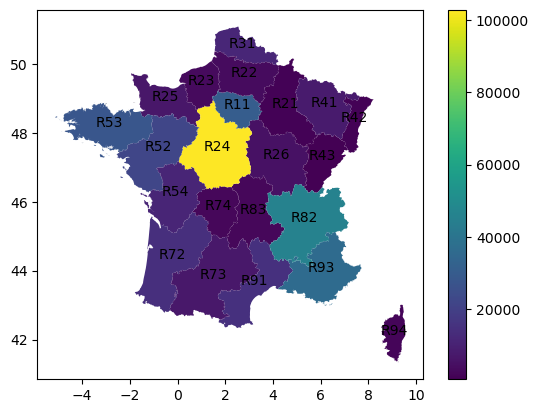

In [63]:
ax = gdf_france.plot(column="ExposureSum", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

In [64]:
region_exposure = claims.group_by("Region").agg(pl.col("Exposure").mean())
region_exposure = region_exposure.to_pandas()
gdf_france = gdf_france.merge(region_exposure, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"Exposure": "ExposureMean"})

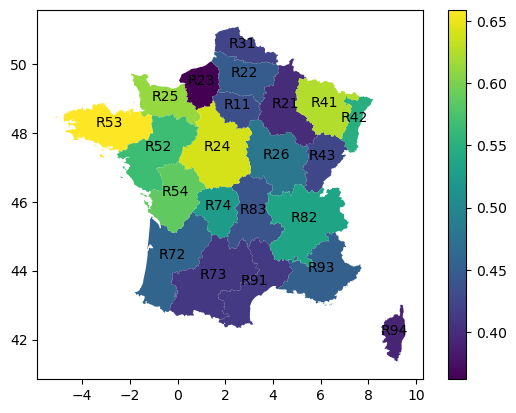

In [65]:
ax = gdf_france.plot(column="ExposureMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

VehPower

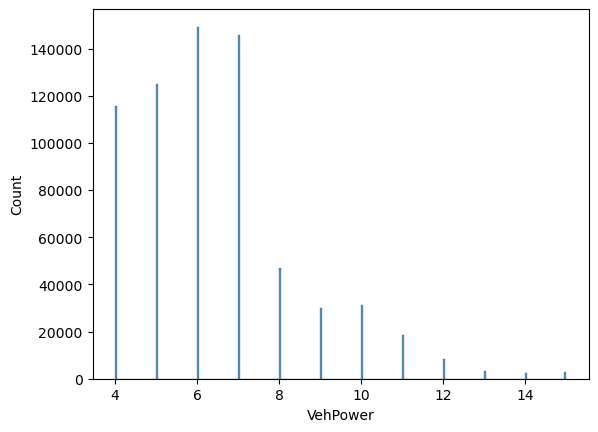

In [66]:
_ = sns.histplot(x=claims["VehPower"])

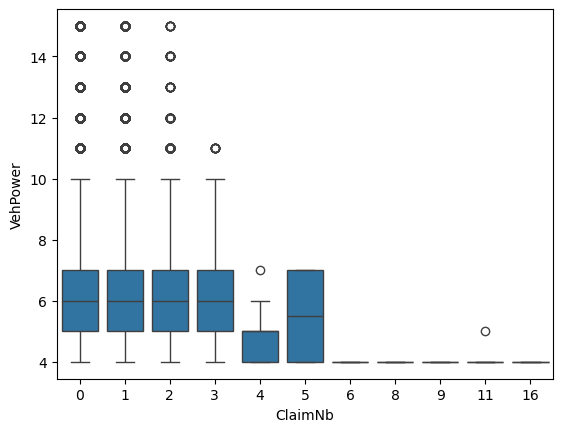

In [67]:
_ = sns.boxplot(y=claims["VehPower"], x=claims["ClaimNb"])

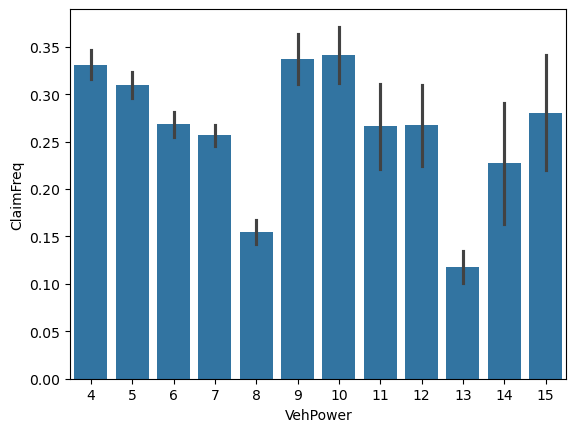

In [68]:
_ = sns.barplot(x=claims["VehPower"], y=claims["ClaimFreq"], errorbar='se')

In [69]:
region_power = claims.group_by("Region").agg(pl.col("VehPower").mean())
region_power = region_power.to_pandas()
gdf_france = gdf_france.merge(region_power, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"VehPower": "VehPowerMean"})

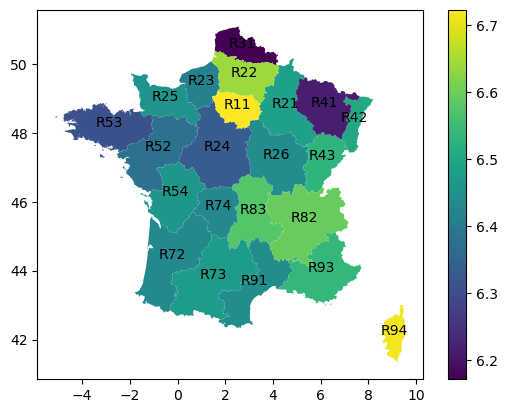

In [70]:
ax = gdf_france.plot(column="VehPowerMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

VehAge

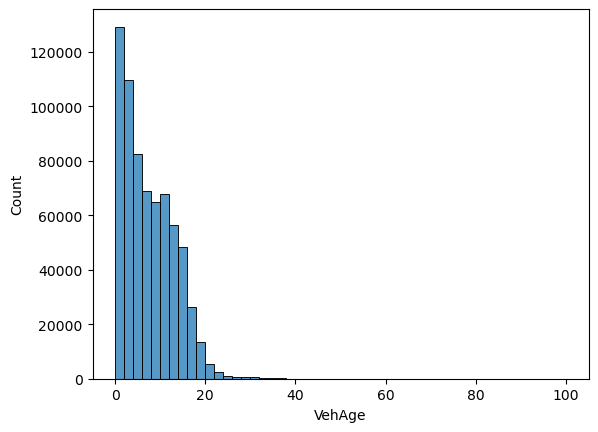

In [71]:
_ = sns.histplot(x=claims["VehAge"], bins=50)

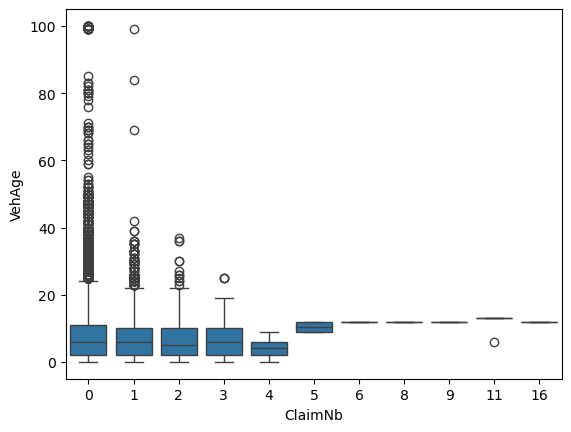

In [72]:
_ = sns.boxplot(x=claims["ClaimNb"], y=claims["VehAge"])

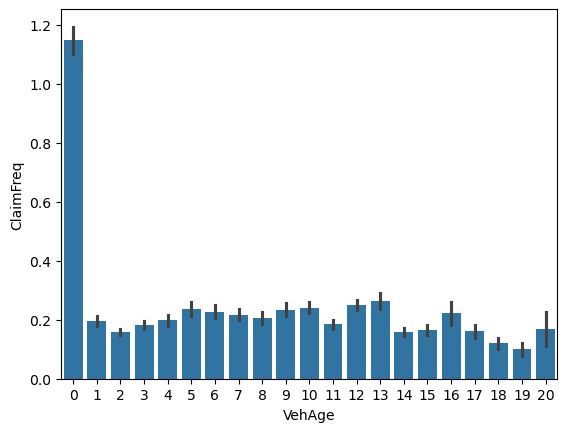

In [73]:
_ = sns.barplot(data=claims.filter(pl.col("VehAge") <= 20), x="VehAge", y="ClaimFreq", errorbar="se")

In [74]:
region_vehage = claims.group_by("Region").agg(pl.col("VehAge").mean())
region_vehage = region_vehage.to_pandas()
gdf_france = gdf_france.merge(region_vehage, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"VehAge": "VehAgeMean"})

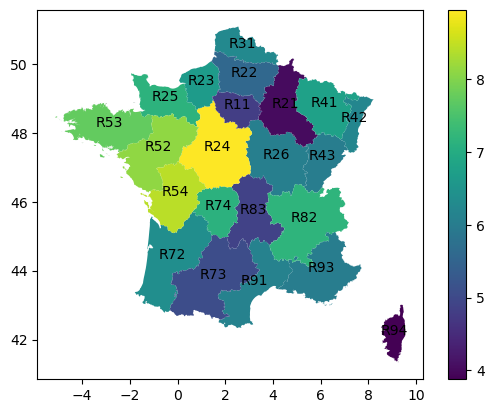

In [75]:
ax = gdf_france.plot(column="VehAgeMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

DrivAge

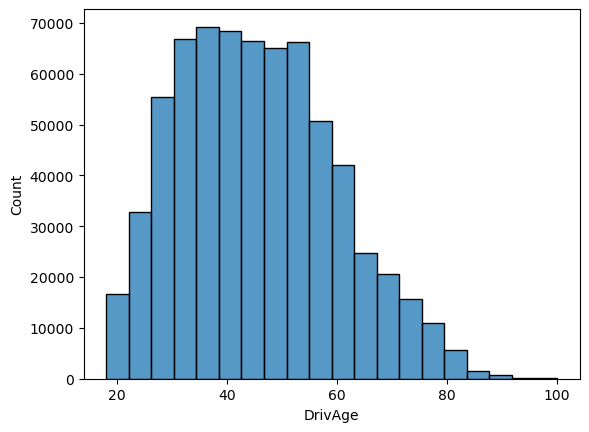

In [76]:
_ = sns.histplot(x=claims["DrivAge"], bins=20)

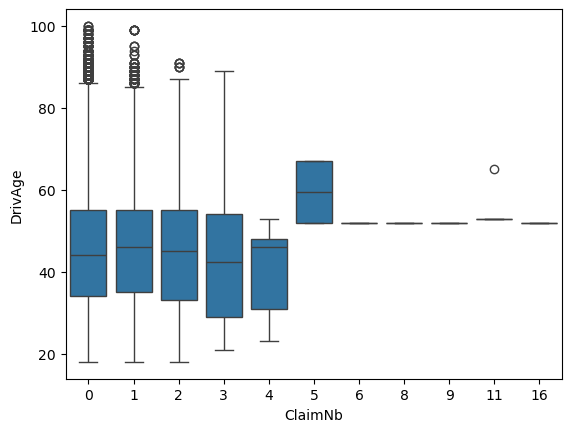

In [77]:
_ = sns.boxplot(x=claims["ClaimNb"], y=claims["DrivAge"])

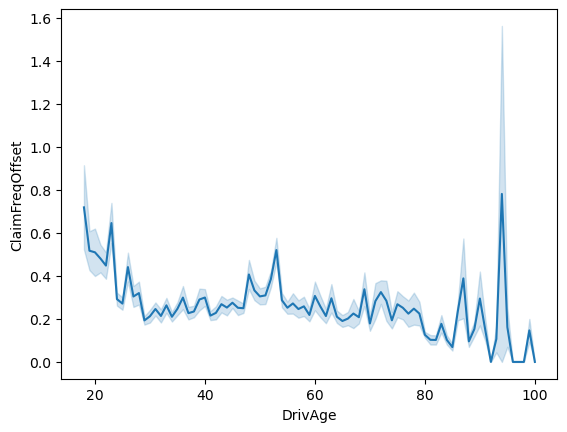

In [78]:
_ = sns.lineplot(data=claims, x="DrivAge", y="ClaimFreqOffset", errorbar="se")

In [79]:
region_drivage = claims.group_by("Region").agg(pl.col("DrivAge").mean())
region_drivage = region_drivage.to_pandas()
gdf_france = gdf_france.merge(region_drivage, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"DrivAge": "DrivAgeMean"})

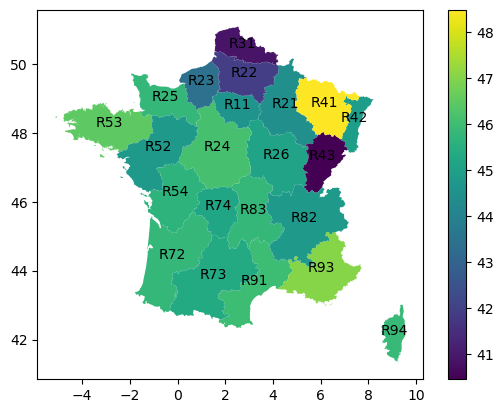

In [80]:
ax = gdf_france.plot(column="DrivAgeMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

Area

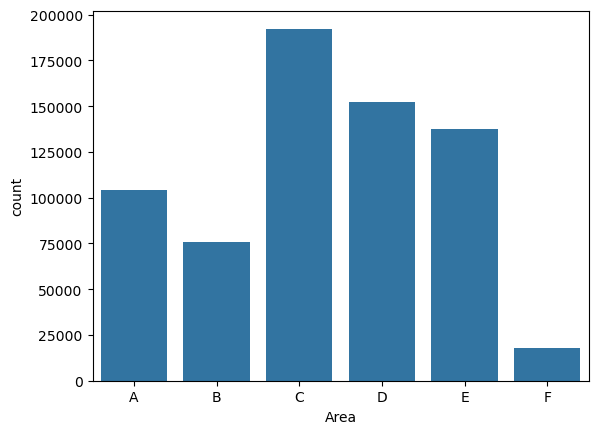

In [81]:
_ = sns.countplot(x=claims["Area"], order=sorted(claims["Area"].unique()))

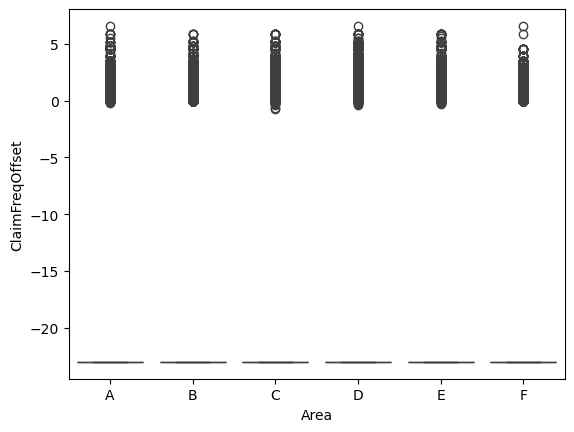

In [82]:
_ = sns.boxplot(x=claims["Area"], y=np.log(claims["ClaimFreqOffset"]), order=sorted(claims["Area"].unique()))

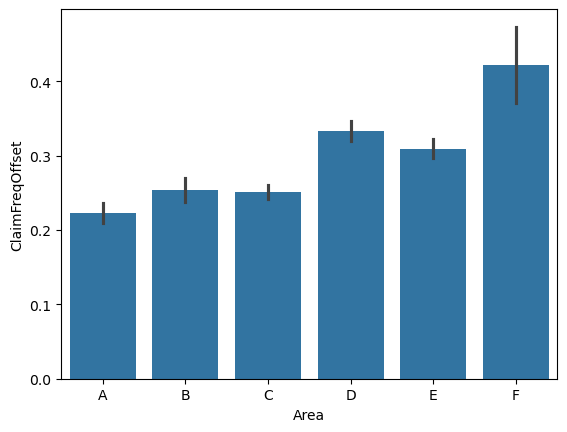

In [83]:
_ = sns.barplot(data=claims, x="Area", y="ClaimFreqOffset", order=sorted(claims["Area"].unique()), errorbar="se")

In [85]:
claims.group_by("Area").agg(pl.col("ClaimFreqOffset").mean()).sort(by="Area")

Area,ClaimFreqOffset
str,f64
"""A""",0.223255
"""B""",0.253764
"""C""",0.25118
"""D""",0.332966
"""E""",0.309323
"""F""",0.421722


BonusMalus

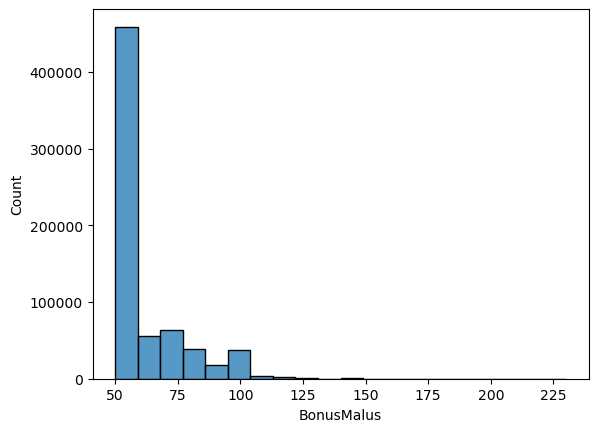

In [86]:
_ = sns.histplot(x=claims["BonusMalus"], bins=20)

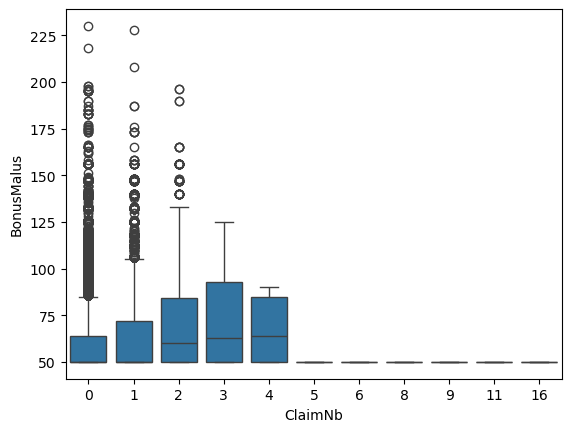

In [87]:
_ = sns.boxplot(x=claims["ClaimNb"], y=claims["BonusMalus"])

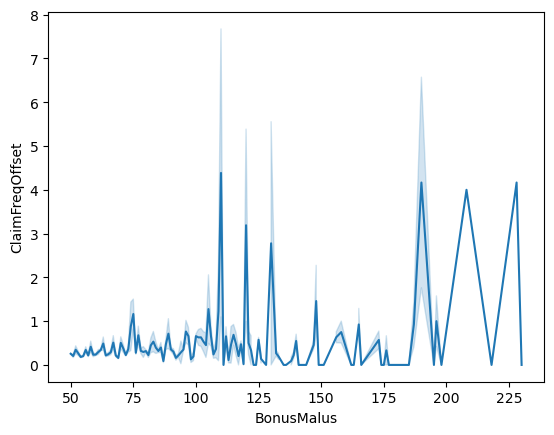

In [88]:
_ = sns.lineplot(data=claims, x="BonusMalus", y="ClaimFreqOffset", errorbar="se")

In [89]:
region_bonusmalus = claims.group_by("Region").agg(pl.col("BonusMalus").mean())
region_bonusmalus = region_bonusmalus.to_pandas()
gdf_france = gdf_france.merge(region_bonusmalus, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"BonusMalus": "BonusMalusMean"})

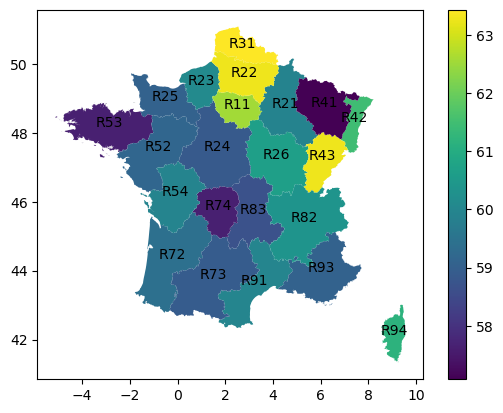

In [90]:
ax = gdf_france.plot(column="BonusMalusMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

VehBrand

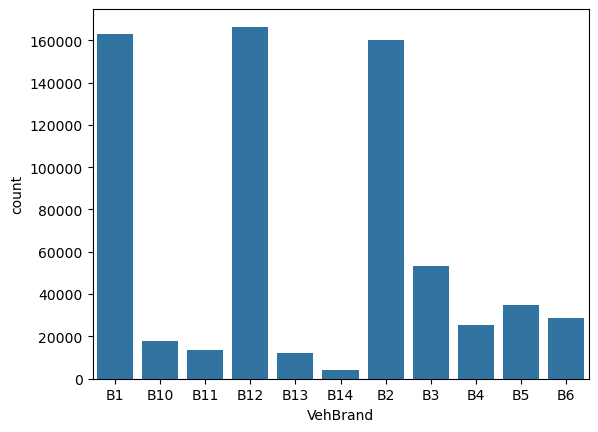

In [91]:
_ = sns.countplot(x=claims["VehBrand"], order=sorted(claims["VehBrand"].unique()))

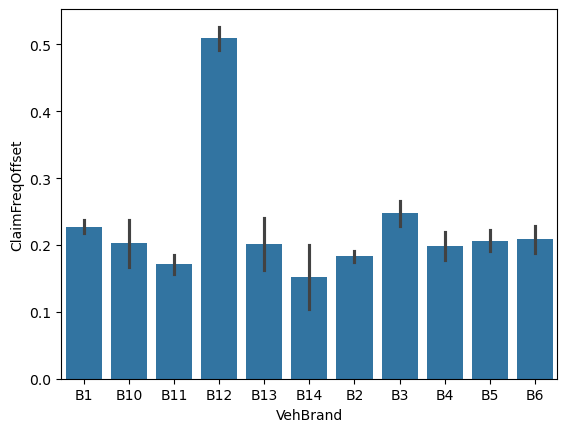

In [92]:
_ = sns.barplot(data=claims, x="VehBrand", y="ClaimFreqOffset", order=sorted(claims["VehBrand"].unique()), errorbar="se")

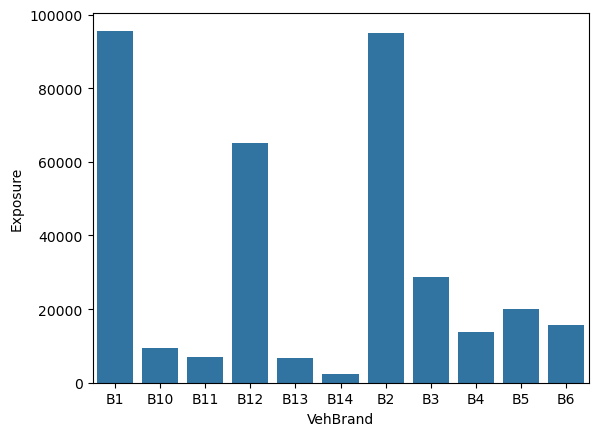

In [93]:
_ = sns.barplot(data=claims, x="VehBrand", y="Exposure", order=sorted(claims["VehBrand"].unique()), estimator=np.sum, errorbar=None)

VehGas

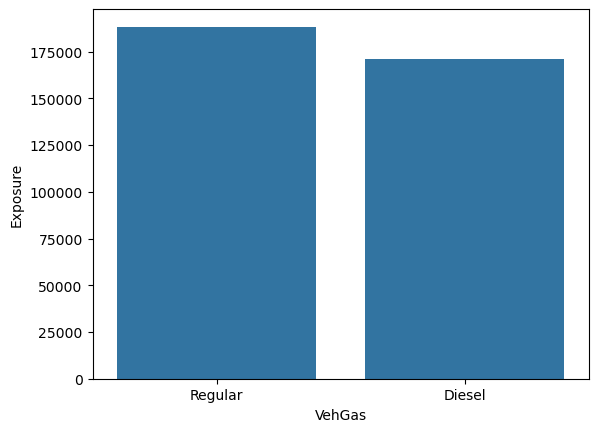

In [94]:
_ = sns.barplot(data=claims, x="VehGas", y="Exposure", estimator=np.sum, errorbar=None)

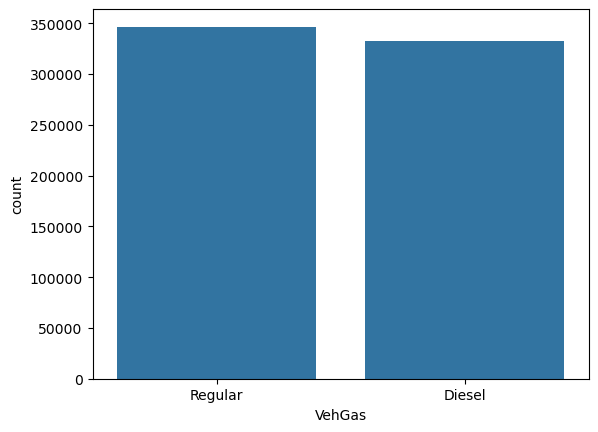

In [95]:
_ = sns.countplot(x=claims["VehGas"])

In [111]:
ct = claims.pivot(on="VehBrand", index="VehGas", values="VehBrand", aggregate_function="len")
ct

VehGas,B12,B6,B3,B2,B5,B10,B14,B13,B4,B1,B11
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""Regular""",90840,17232,23648,75199,17993,4690,2750,6106,13841,87438,6890
"""Diesel""",75558,11379,29872,84980,16842,13050,1301,6100,11384,75687,6733


In [112]:
brand_cols = [c for c in ct.columns if c != "VehGas"]

# Divide each brand column by its own sum
ct_normalized = ct.with_columns(
    [
        (pl.col(c) / pl.col(c).sum()).alias(c)
        for c in brand_cols
    ]
)
ct_normalized

VehGas,B12,B6,B3,B2,B5,B10,B14,B13,B4,B1,B11
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Regular""",0.54592,0.602286,0.441854,0.469469,0.516521,0.264374,0.678845,0.500246,0.548702,0.536018,0.505762
"""Diesel""",0.45408,0.397714,0.558146,0.530531,0.483479,0.735626,0.321155,0.499754,0.451298,0.463982,0.494238


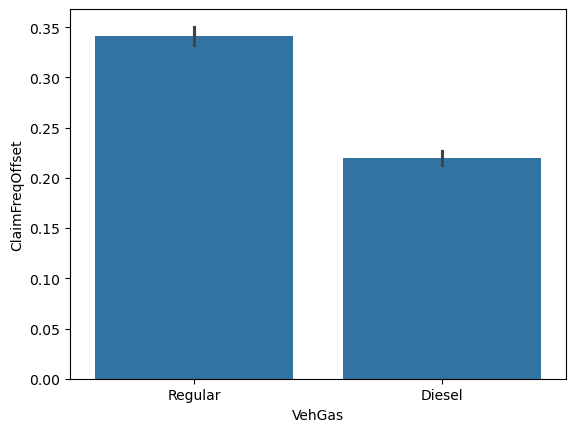

In [113]:
_ = sns.barplot(data=claims, x="VehGas", y="ClaimFreqOffset", errorbar='se')

In [114]:
ct = claims.pivot(on="Region", index="VehGas", values="Region", aggregate_function="len")
ct

VehGas,R82,R22,R72,R31,R91,R52,R93,R11,R24,R94,R83,R54,R26,R53,R73,R42,R25,R21,R41,R43,R74,R23
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""Regular""",45436,3599,15304,11730,18108,19566,43267,42543,77127,2434,2340,9304,5228,20866,7741,1358,5283,1229,7631,646,1914,3973
"""Diesel""",39547,4407,16095,15627,17831,19263,36281,27446,83687,2105,2953,9777,5281,21334,9419,851,5633,1804,5375,682,2666,4822


In [115]:
region_cols = [c for c in ct.columns if c != "VehGas"]

# Divide each brand column by its own sum
ct_normalized = ct.with_columns(
    [
        (pl.col(c) / pl.col(c).sum()).alias(c)
        for c in region_cols
    ]
)
ct_normalized

VehGas,R82,R22,R72,R31,R91,R52,R93,R11,R24,R94,R83,R54,R26,R53,R73,R42,R25,R21,R41,R43,R74,R23
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Regular""",0.534648,0.449538,0.487404,0.428775,0.503854,0.503902,0.543911,0.607853,0.479604,0.536241,0.442093,0.487605,0.497478,0.494455,0.451107,0.614758,0.483968,0.405209,0.586729,0.486446,0.417904,0.451734
"""Diesel""",0.465352,0.550462,0.512596,0.571225,0.496146,0.496098,0.456089,0.392147,0.520396,0.463759,0.557907,0.512395,0.502522,0.505545,0.548893,0.385242,0.516032,0.594791,0.413271,0.513554,0.582096,0.548266


Density

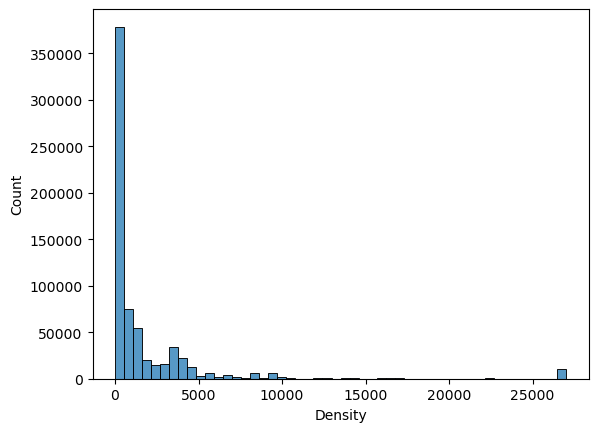

In [116]:
_ = sns.histplot(x=claims["Density"], bins=50)

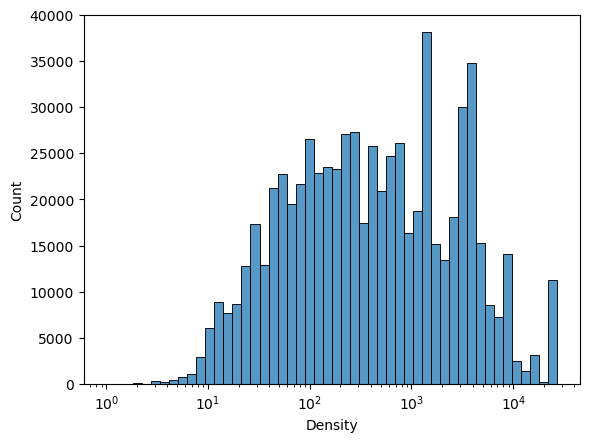

In [117]:
_ = sns.histplot(x=claims["Density"], log_scale=True, bins=50)

In [129]:
claims = claims.with_columns(pl.col("Density").log(base=10).alias("logDensity"))

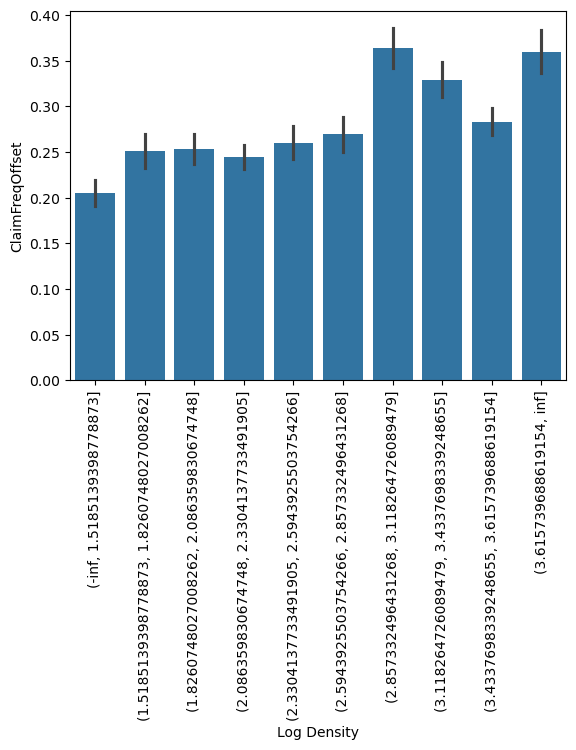

In [130]:
ax = sns.barplot(x=claims["logDensity"].qcut(10) , y=claims["ClaimFreqOffset"], errorbar="se",
                 order=sorted(claims["logDensity"].qcut(10).unique()))
_ = plt.xticks(rotation=90)
_ = plt.xlabel("Log Density")

In [131]:
region_logdensity = claims.group_by("Region").agg(pl.col("logDensity").mean())
region_logdensity = region_logdensity.to_pandas()
gdf_france = gdf_france.merge(region_logdensity, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"logDensity": "logDensityMean"})

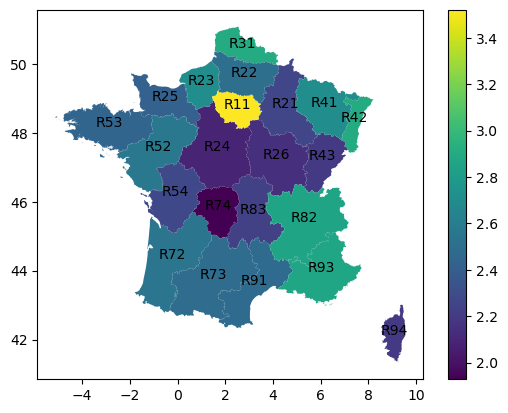

In [132]:
ax = gdf_france.plot(column="logDensityMean", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);

Region

In [133]:
region_counts = claims.group_by("Region").agg(pl.col("ClaimNb").count())
region_counts = region_counts.to_pandas()
gdf_france = gdf_france.merge(region_counts, how="left", on="Region")
gdf_france = gdf_france.rename(columns={"ClaimNb": "PolicyCounts"})

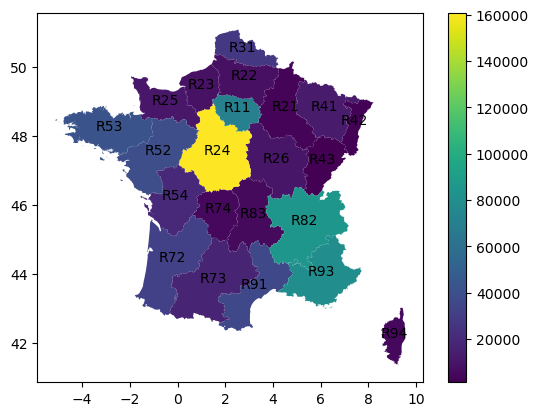

In [134]:
ax = gdf_france.plot(column="PolicyCounts", legend=True)
gdf_france.apply(lambda x: ax.annotate(text=x['Region'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1);